In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv('environmental factors.csv')
print(data.head())

   temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    22.490802  52.418449   19.599966        337.165056        369.020837   
1    34.014286  49.974726    8.690240        256.681604        185.335998   
2    29.639879  40.569235   11.932794        484.024336        213.723302   
3    26.973170  66.436000   18.265613        148.540303        262.604015   
4    18.120373  58.597450   14.641787        314.535387        283.288001   

   pollution_level  
0        84.723658  
1        49.451704  
2        19.546561  
3        73.664179  
4        41.867814  


In [3]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
print(pd.DataFrame(data_scaled,columns=data.columns).head())

   temperature  humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    -0.415900 -0.452465    0.801884          0.482494         -0.684316   
1     1.587377 -0.593258   -1.100359         -0.136414         -1.389866   
2     0.826917 -1.135149   -0.534981          1.611824         -1.280827   
3     0.363328  0.355146    0.569224         -0.968007         -1.093072   
4    -1.175669 -0.096466   -0.062635          0.308475         -1.013623   

   pollution_level  
0         1.193409  
1        -0.029923  
2        -1.067119  
3         0.809835  
4        -0.292954  


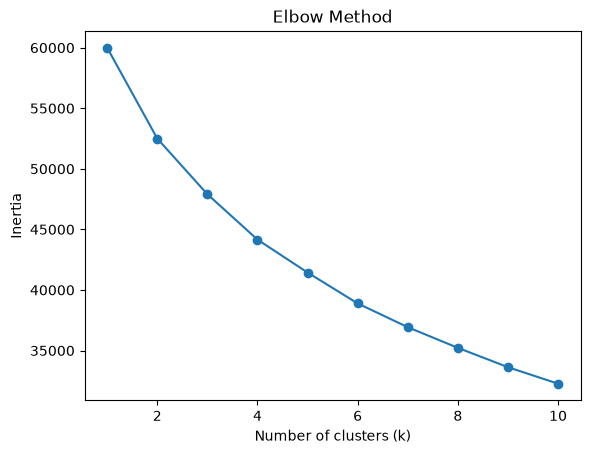

In [4]:
inertia = []
k_range = range(1,11)

for k in k_range:
 kmeans = KMeans(n_clusters=k,random_state=42)
 kmeans.fit(data_scaled)
 inertia.append(kmeans.inertia_)

plt.plot(k_range,inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [5]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
data['cluster'] = kmeans.fit_predict(data_scaled)
data.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level,cluster
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658,2
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704,1
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561,0
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179,1
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814,2


In [6]:
data['cluster'].unique()

array([2, 1, 0], dtype=int32)

In [7]:
sil_score = silhouette_score(data_scaled,data['cluster'])
print(f'silhouette Score: {sil_score}')

silhouette Score: 0.11105304055163615


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.scatterplot(x='carbon_emissions', y='pollution_level', hue='cluster', data=data, palette='viridis', s=100, alpha=0.7, edgecolor='k')

plt.title('K-means clustering of Environmental Factors')
plt.xlabel('Carbon Emissions')
plt.ylabel('Pollution Level')
plt.legend(title='cluster',bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()